In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

In [2]:
train_df = pd.read_csv("train.csv",index_col= "id")

In [3]:
train_df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
id,,,,,,,,,,,,,
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [4]:
numerical_cols = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'age'
]

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(train_df[numerical_cols])

# Iterative imputer
imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

imputed_data = imputer.fit_transform(scaled_data)

# Convert back to original scale
imputed_data = scaler.inverse_transform(imputed_data)

# Put values back into dataframe
train_df[numerical_cols] = imputed_data

c:\Users\bobs9\OneDrive\Desktop\DS-ML-Project1\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [6]:
categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact"
    
]

train_df[categorical_cols] = train_df[categorical_cols].fillna("Unknown")


train_df = pd.get_dummies(
    train_df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [7]:
train_df.isnull().sum()

age                             0
daily_screen_time_hours         0
social_media_hours              0
gaming_hours                    0
work_study_hours                0
sleep_hours                     0
notifications_per_day           0
app_opens_per_day               0
weekend_screen_time             0
addicted_label                  0
gender_Male                     0
gender_Other                    0
gender_Unknown                  0
stress_level_Low                0
stress_level_Medium             0
stress_level_Unknown            0
academic_work_impact_Unknown    0
academic_work_impact_Yes        0
dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
X = train_df.drop(columns = "addicted_label")
y = train_df[["addicted_label"]]

In [10]:
X_train , X_test ,y_train ,y_test = train_test_split(X, y ,test_size= 0.2, random_state= 999, stratify= y)

In [11]:
scaler =StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [12]:
model = LogisticRegression().fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

c:\Users\bobs9\OneDrive\Desktop\DS-ML-Project1\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [13]:
accuracy_score(y_test , y_pred)

0.8484675354730463

In [14]:
confusion_matrix(y_test , y_pred)

array([[28640, 11539],
       [ 9414, 88681]])

In [15]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.75      0.71      0.73     40179
           1       0.88      0.90      0.89     98095

    accuracy                           0.85    138274
   macro avg       0.82      0.81      0.81    138274
weighted avg       0.85      0.85      0.85    138274



The above was done for training data set, where the target value and predicted values are compared with each other.

___
___

## Actually predicting on Test.csv

In [16]:
test_df = pd.read_csv("test.csv",index_col= "id")
test_df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
id,,,,,,,,,,,,
691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [17]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(test_df[numerical_cols])

# Iterative imputer
imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

imputed_data = imputer.fit_transform(scaled_data)

# Convert back to original scale
imputed_data = scaler.inverse_transform(imputed_data)

# Put values back into dataframe
test_df[numerical_cols] = imputed_data

c:\Users\bobs9\OneDrive\Desktop\DS-ML-Project1\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [18]:
categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact"
    
]

test_df[categorical_cols] = test_df[categorical_cols].fillna("Unknown")


test_df = pd.get_dummies(
    test_df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [19]:
test_df.isnull().sum()

age                             0
daily_screen_time_hours         0
social_media_hours              0
gaming_hours                    0
work_study_hours                0
sleep_hours                     0
notifications_per_day           0
app_opens_per_day               0
weekend_screen_time             0
gender_Male                     0
gender_Other                    0
gender_Unknown                  0
stress_level_Low                0
stress_level_Medium             0
stress_level_Unknown            0
academic_work_impact_Unknown    0
academic_work_impact_Yes        0
dtype: int64

In [20]:
X_test_scaled = scaler.fit_transform(test_df)

In [44]:
y_pred = model.predict(X_test_scaled)

In [45]:
y_pred_df = pd.DataFrame(y_pred)

<Axes: xlabel='0'>

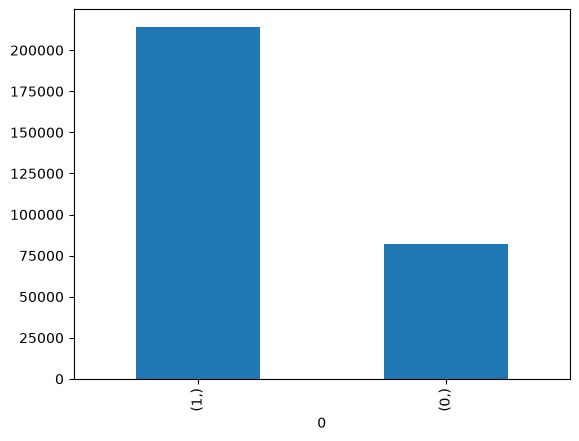

In [23]:
y_pred_df.value_counts().plot(kind = "bar" )

___
___

## For kaggle making csv file for storing the values

In [46]:
y_pred_df.count()

0    296302
dtype: int64

In [49]:
y_pred_df = y_pred_df.rename(columns={0:"addicted_label"})

In [50]:
y_pred_df

,addicted_label
0,1
1,1
2,1
3,1
4,1
...,...
296297,1
296298,1
296299,0
296300,0


In [51]:
y_pred_df.to_csv("addicted_label_of_test.csv")

___
___